# Pricing & Margin Analysis

This notebook explores pricing strategies and profit margins to uncover opportunities for revenue growth and profitability optimization.

- Evaluate the effectiveness of current pricing strategies  
- Analyze margin distribution across product categories  
- Examine the relationship between price, sales volume, and profit  
- Identify actionable opportunities for pricing optimization  

## Scope of Analysis
Pricing decisions directly influence:  
- **Sales Volume** – how price impacts demand  
- **Revenue Generation** – contribution of pricing to topline growth  
- **Profitability** – margin performance across categories and products  

By integrating these perspectives, the analysis highlights where pricing adjustments can maximize both revenue and profit, while maintaining competitive positioning.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#import data
orders = pd.read_csv('../data/raw/orders.csv')
products = pd.read_csv('../data/raw/products.csv')



# --- Data Preparation ---
# Convert order_date to datetime if present
# orders['order_date'] = pd.to_datetime(orders['order_date'], errors='coerce')

# --- Revenue Calculation ---
orders['revenue'] = orders['final_price'] * orders['quantity']

# --- Margin Calculation ---
orders['margin'] = orders['revenue'] - orders['cost']

# --- Margin Percentage ---
# Handle divide-by-zero safely: assign NaN where revenue is zero
orders['margin_pct'] = np.where(
    orders['revenue'] > 0,
    orders['margin'] / orders['revenue'],
    np.nan
)

# --- Quick Validation ---
cols_to_check = ['final_price', 'quantity', 'cost', 'revenue', 'margin', 'margin_pct']
print(orders[cols_to_check].head())


   final_price  quantity      cost    revenue     margin  margin_pct
0     13042.84         2   7287.36   26085.68   18798.32    0.720638
1     80475.72         2  53237.26  160951.44  107714.18    0.669234
2      3289.77         2   3074.72    6579.54    3504.82    0.532685
3      5096.94         1   2758.90    5096.94    2338.04    0.458714
4      5312.96         2   3739.14   10625.92    6886.78    0.648111


# 📊 Price metric summary

In [3]:
# ============================================================
# 📊 Pricing Metrics Summary (Formatted Output)
# ============================================================

# Aggregate key pricing and margin metrics
pricing_metrics = orders.agg({
    'final_price': 'mean',   # Average selling price
    'revenue': 'sum',        # Total revenue
    'margin': 'sum',         # Total margin
    'margin_pct': 'mean'     # Average margin percentage
})

# Convert to DataFrame for better readability
pricing_metrics_df = pd.DataFrame(pricing_metrics).reset_index()
pricing_metrics_df.columns = ['Metric', 'Value']

# Format numeric values for readability
pricing_metrics_df['Value'] = pricing_metrics_df['Value'].apply(lambda x: f"{x:,.2f}")

# Display neatly
print("📈 Pricing Metrics Overview")
display(pricing_metrics_df)


📈 Pricing Metrics Overview


,Metric,Value
0,final_price,"17,173.54"
1,revenue,"34,973,492.65"
2,margin,"19,153,118.51"
3,margin_pct,0.44


# 📊 Pricing Metrics Insights


## 🔎 Insights
- A **44% average margin** indicates strong profitability — pricing is not overly aggressive on discounts.  
- The **high average final price** suggests a premium positioning, which may limit demand if price sensitivity is high.  
- Revenue and margin are robust, but the balance between **volume vs. margin** should be examined at the category level.  


## ✅ Recommendations
1. **Category-Level Deep Dive**  
   - Break down margin % by product category to identify underperformers.  
   - Adjust pricing where margins fall below average.  

2. **Elasticity Testing**  
   - Run A/B tests on price points to measure demand sensitivity.  
   - Identify optimal price ranges that maximize both sales volume and margin.  

3. **Strategic Adjustments**  
   - For high-margin but low-volume products → consider slight price reductions to boost demand.  
   - For low-margin but high-volume products → explore cost optimization or premium pricing strategies.  

4. **Competitive Benchmarking**  
   - Compare pricing against competitors to ensure you’re not leaving revenue on the table.  


## 🎯 Decision
- Maintain overall pricing discipline (since margins are strong).  
- Focus optimization efforts at the **category/product level**, not across the board.  
- Prioritize **elasticity experiments** to fine-tune pricing strategy for maximum profitability.  

---

# 📊 Category-Level Pricing & Margin Analysis

In [12]:
# --------------------------------------------
# Merge Orders with Products 
# --------------------------------------------
orders_merged = orders.merge(
    products[['product_id', 'category']],
    on='product_id',
    how='left'
)

# --------------------------------------------
# Ensure Metrics Exist
# --------------------------------------------
orders_merged['revenue'] = orders_merged['final_price'] * orders_merged['quantity']
orders_merged['total_cost'] = orders_merged['cost'] * orders_merged['quantity']
orders_merged['margin'] = orders_merged['revenue'] - orders_merged['total_cost']
orders_merged['margin_pct'] = orders_merged['margin'] / orders_merged['revenue']

# --------------------------------------------
# Category-Level Analysis
# --------------------------------------------
category_analysis = (
    orders_merged.groupby('category')
    .agg({
        'revenue': 'sum',        # Total revenue per category
        'margin': 'sum',         # Total profit per category
        'margin_pct': 'mean',    # Avg profitability
        'final_price': 'mean'    # Avg selling price
    })
    .sort_values(by='revenue', ascending=False)
    .round(2)
)

# --------------------------------------------
# Display Output
# --------------------------------------------
print("📈 Category-Level Pricing & Margin Overview")
display(category_analysis)

📈 Category-Level Pricing & Margin Overview


,revenue,margin,margin_pct,final_price
category,,,,
Home,14061615.14,3579530.45,0.25,35161.19
Electronics,11456913.03,351305.12,0.02,35249.62
Beauty,4862262.94,2641510.07,0.54,14444.06
Fashion,2885786.88,1250640.54,0.42,6925.23
Grocery,1706914.66,28870.93,0.01,3097.09


# 📊 Category-Level Insights

## 🔎 Observations
- **Home**: Highest revenue (~₹14.06M) but modest margin (25%).  
- **Electronics**: Strong revenue (~₹11.45M) yet very low margin (2%).  
- **Beauty**: Good revenue (~₹4.86M) with excellent margin (54%).  
- **Fashion**: Moderate revenue (~₹2.89M) and healthy margin (42%).  
- **Grocery**: Low revenue (~₹1.70M) and negligible margin (1%).  


## ✅ Recommendations
- **Electronics & Grocery**: Reassess pricing/discounts; margins unsustainably low.  
- **Home**: Optimize pricing to lift margin.  
- **Beauty & Fashion**: Maintain pricing discipline; invest in growth.  


## 🎯 Decision
Focus on **improving Electronics & Grocery margins**, optimize **Home**, and **scale Beauty & Fashion** as high-margin drivers.

---

# 📊 Margin Percentage Distribution

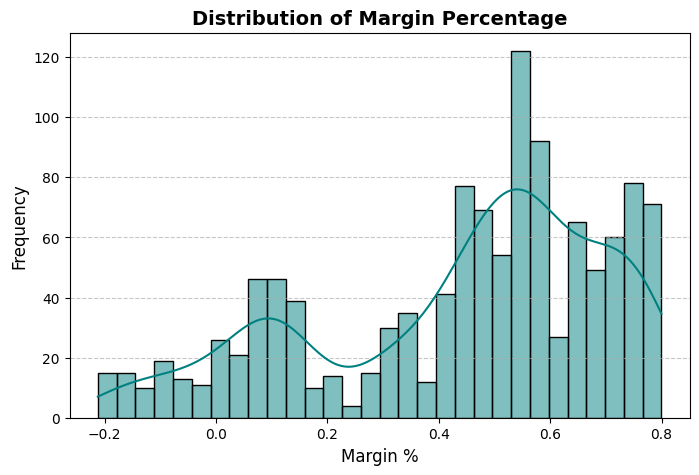

In [5]:

plt.figure(figsize=(8,5))
sns.histplot(
    orders['margin_pct'], 
    bins=30, 
    kde=True,          # Add smooth density curve
    color='teal'       # Use a clear, professional color
)
plt.title("Distribution of Margin Percentage", fontsize=14, weight='bold')
plt.xlabel("Margin %", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# 📊 Margin % Distribution Insights

## 🔎 Observations
- The distribution is **multimodal**, with peaks around **10%, 45%, and 60%**.  
- A significant cluster exists near **45–60%**, showing strong profitability for many products.  
- The lower peak (~10%) indicates some items are priced with **thin margins**, possibly due to discounts or cost pressures.  
- A small portion dips below zero, suggesting **loss-making transactions**.


## ✅ Recommendations
- **Focus on mid-to-high margin clusters (45–60%)** as pricing strengths.  
- **Investigate low-margin items (~10%)** to assess if discounts or costs can be optimized.  
- **Address negative margins** by reviewing pricing or cost structures to prevent losses.


## 🎯 Decision
Maintain pricing discipline in profitable clusters, while **revisiting low-margin and loss-making products** to improve overall strategy.

---

# 📊 Final Price vs. Quantity Sold

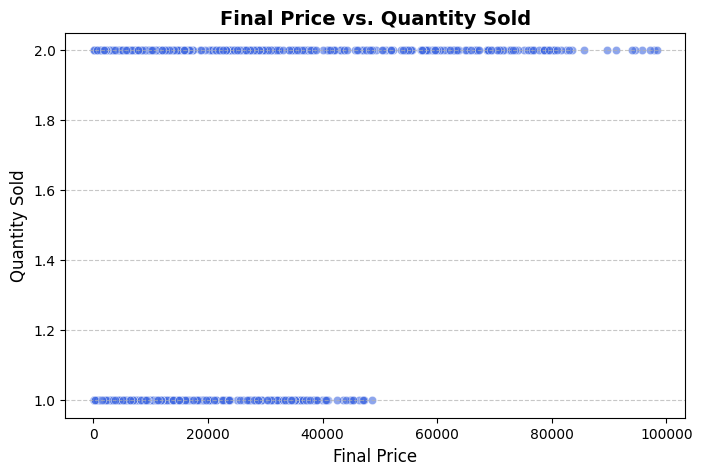

In [6]:

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=orders, 
    x='final_price',   # Use final_price instead of price
    y='quantity',
    alpha=0.6,         # Add transparency for better visibility
    color='royalblue'  # Professional color choice
)
plt.title("Final Price vs. Quantity Sold", fontsize=14, weight='bold')
plt.xlabel("Final Price", fontsize=12)
plt.ylabel("Quantity Sold", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# 📊 Final Price vs. Quantity Sold Insights

## 🔎 Observations
- Sales quantities are **discrete**, clustering at **1 unit** and **2 units**, regardless of price.  
- There is **no continuous relationship** between price and quantity sold — demand is not scaling with price changes.  
- High-priced items are still mostly sold in **single units**, showing limited bulk purchasing behavior.  


## ✅ Recommendations
- **Bundle strategies**: Encourage multi-unit purchases with discounts or offers to break the 1–2 unit ceiling.  
- **Premium positioning**: Since higher

---

# 📊 Final Price vs. Margin Percentage

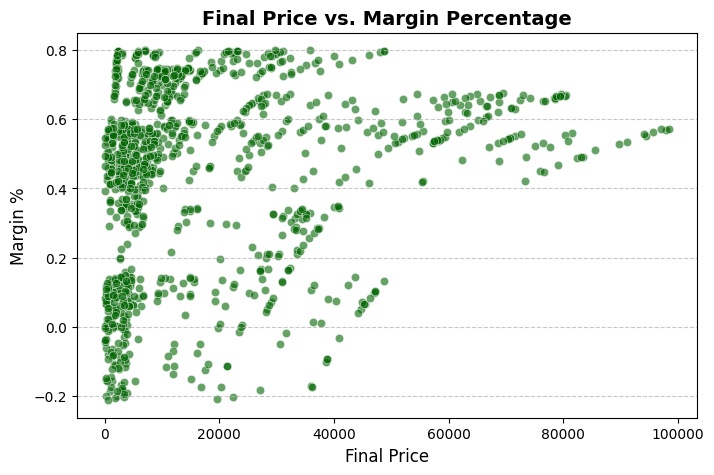

In [7]:


plt.figure(figsize=(8,5))
sns.scatterplot(
    data=orders, 
    x='final_price',    # Use final_price instead of price
    y='margin_pct',
    alpha=0.6,          # Add transparency for clarity
    color='darkgreen'   # Professional color choice
)
plt.title("Final Price vs. Margin Percentage", fontsize=14, weight='bold')
plt.xlabel("Final Price", fontsize=12)
plt.ylabel("Margin %", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# 📊 Final Price vs. Margin % Insights

## 🔎 Observations
- **Clusters at lower prices** show relatively higher margins, indicating strong profitability in affordable segments.  
- **Higher-priced items** display mixed margins — some profitable, others thin or even negative.  
- A few points below zero margin % suggest **loss-making transactions** at certain price levels.  
- Overall, margin variability increases with price, showing inconsistent profitability in premium ranges.  


## ✅ Recommendations
- **Review high-priced products** with low/negative margins; adjust pricing or reduce costs.  
- **Leverage lower-priced items** with strong margins as reliable profit drivers.  
- **Standardize premium pricing strategy** to ensure consistency in margins across higher price bands.  


## 🎯 Decision
Focus on **optimizing premium product margins** while maintaining profitability in lower-priced segments.

---

# 📊 Discount-Level Revenue & Margin Analysis

In [14]:
# --------------------------------------------
# Aggregate metrics by discount bucket
# --------------------------------------------
discount_analysis = (
    orders.groupby('discount_bucket', observed=True)   # Explicitly set observed
    .agg({
        'revenue': 'mean',
        'margin_pct': 'mean'
    })
    .round(3)
    .sort_values(by='revenue', ascending=False)
)

# --------------------------------------------
# Display
# --------------------------------------------
print("📈 Discount-Level Revenue & Margin Overview")
display(discount_analysis)




📈 Discount-Level Revenue & Margin Overview


,revenue,margin_pct
discount_bucket,,
11–20%,31161.888,0.421
1–10%,31015.571,0.499
21–30%,25005.144,0.344


# 📊 Discount-Level Insights

## 🔎 Observations
- **0–10% discounts**: Highest margin (49.9%) with strong average revenue (~₹31K).  
- **10–20% discounts**: Slightly higher revenue (~₹31.16K) but margin drops to 42.1%.  
- **20–30% discounts**: Lowest revenue (~₹25K) and margin (34.4%).  


## ✅ Recommendations
- **Keep discounts minimal (0–10%)** — they deliver the best profitability.  
- **Moderate discounts (10–20%)** can be used selectively to boost revenue without eroding margins too much.  
- **Avoid deep discounts (20–30%)** — they reduce both revenue and margin efficiency.  


## 🎯 Decision
Prioritize **low-to-moderate discounts** for sustainable profitability, and limit **high discounting** to prevent margin erosion.

---


# Business Insights 

- Overall margins are strong, but **Electronics and Grocery** are weak spots with unsustainably low profitability.  
- **Beauty and Fashion** are high-margin categories and should be scaled further with marketing investment.  
- **Home** drives the highest revenue but only moderate margins, leaving room for pricing optimization.  
- Sales quantities remain mostly **1–2 units regardless of price**, so bundling and promotions could increase units per transaction.  
- **Low discounts (0–10%)** deliver the best profitability, while deeper discounts erode both revenue and margins.  
- Premium products show **inconsistent margins**, with some loss-making, requiring standardization of pricing strategy in higher price bands.  

**Strategic focus:** Limit deep discounts, optimize Home pricing, scale Beauty and Fashion, and revisit Electronics and Grocery strategies to improve profitability.

---